In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### initialise vars

In [2]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

news_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [3]:
peacock_urls = [
    'https://www.instagram.com/peacock/reel/DSEC7pojf3H/',
    'https://www.instagram.com/peacock/reel/DSEFSQJAGeV/',
    'https://www.instagram.com/peacock/p/DSD45vFgDBd/',
    'https://www.instagram.com/peacock/reel/DSDUvgsgLqk/',
    'https://www.instagram.com/belairpeacock/reel/DSDOHnBCS0t/',
    'https://www.instagram.com/nbc/reel/DSDOHj2kr00/',
    'https://www.instagram.com/spotify/reel/DSDN0oCDkGb/',
    'https://www.instagram.com/peacock/p/DSDAUdIgDUw/',
    'https://www.instagram.com/peacock/reel/DSBm_S8gC1p/',
    'https://www.instagram.com/peacock/reel/DSBZZEcgL4D/',
]

nytcooking_urls = [
    'https://www.instagram.com/nytcooking/reel/DSD_gy1DcX5/',
    'https://www.instagram.com/nytcooking/p/DSDwcgkk1qn/',
    'https://www.instagram.com/nytcooking/p/DSDitvpAZUH/',
    'https://www.instagram.com/nytcooking/p/DSDb1UoknQg/',
    'https://www.instagram.com/nytcooking/p/DSDU8zokpV3/',
    'https://www.instagram.com/nytcooking/p/DSDOaPWk4bv/',
    'https://www.instagram.com/nytcooking/p/DSDSO3Fkwax/',
    'https://www.instagram.com/nytcooking/reel/DSDNChjDjIB/',
    'https://www.instagram.com/nytcooking/p/DSC_QAgks4q/',
    'https://www.instagram.com/nytcooking/p/DSDBAbzjifA/',
]

espn_urls = [
    'https://www.instagram.com/espn/reel/DSEgVgeAPWE/',
    'https://www.instagram.com/espncfb/p/DSEWMX5jGnh/',
    'https://www.instagram.com/espn/reel/DSEVBjZAOdU/',
    'https://www.instagram.com/espn/p/DSEOlBoDCRb/',
    'https://www.instagram.com/espn/p/DSEMouEjLXr/',
    'https://www.instagram.com/espn/p/DSELB0fjEiG/',
    'https://www.instagram.com/espn/p/DSEIW-zjJXe/',
    'https://www.instagram.com/espn/p/DSD6pTxgdJv/',
    'https://www.instagram.com/espn/p/DSDrfEyDxs-/',
    'https://www.instagram.com/espn/p/DSDjBkeEiVo/',
]

catloversclub_urls = [
    'https://www.instagram.com/catloversclub/reel/DSEn813Eo5Q/',
    'https://www.instagram.com/catloversclub/reel/DSEHOC8kufg/',
    'https://www.instagram.com/catloversclub/p/DSDzLhlkniQ/',
    'https://www.instagram.com/catloversclub/p/DSC60BKkrYV/',
    'https://www.instagram.com/catloversclub/reel/DSBk9RQEmtF/',
    'https://www.instagram.com/catloversclub/p/DSBQuBCEg6f/',
    'https://www.instagram.com/catloversclub/p/DSARqDnEhPJ/',
    'https://www.instagram.com/catloversclub/p/DR_mqpKEr01/',
    'https://www.instagram.com/catloversclub/reel/DR_fCEnEmtA/',
    'https://www.instagram.com/catloversclub/p/DR-_MPRkurr/',
]

thedogist_urls = [
    'https://www.instagram.com/thedogist/p/DSDe6u8kS6O/',
    'https://www.instagram.com/thedogist/reel/DR-aHhzkXgF/',
    'https://www.instagram.com/thedogist/reel/DR72mfKEedE/',
    'https://www.instagram.com/empirestatebldg/reel/DR7aTBTkebB/',
    'https://www.instagram.com/thedogist/p/DR5O3P_jycm/',
    'https://www.instagram.com/thedogist/reel/DR4mTwyESDm/',
    'https://www.instagram.com/thedogist/reel/DR2VEONkdPT/',
    'https://www.instagram.com/thedogist/reel/DRw-IF6EaT_/',
    'https://www.instagram.com/thedogist/p/DRqGWbcEVvW/',
    'https://www.instagram.com/thedogist/reel/DRnCa95EcVk/',
]

thegradecricketer = [
    'https://www.instagram.com/thegradecricketer/reel/DSEuOIXEsI6/',
    'https://www.instagram.com/thegradecricketer/reel/DSERcMKEs-k/',
    'https://www.instagram.com/thegradecricketer/reel/DSEC3JekvxZ/',
    'https://www.instagram.com/thegradecricketer/reel/DSCJfZ8jKrQ/',
    'https://www.instagram.com/kayosports/reel/DSB-wRmE6MH/',
    'https://www.instagram.com/triplemcricket/reel/DR_3mtdjCre/',
    'https://www.instagram.com/thegradecricketer/reel/DR_CMYYku_p/',
    'https://www.instagram.com/thegradecricketer/reel/DR9nU3FkhGV/',
    'https://www.instagram.com/thegradecricketer/reel/DR7tgNXgCeL/',
    'https://www.instagram.com/thegradecricketer/reel/DR5bFbrgFP0/',
]

pbsfood_urls = [
    'https://www.instagram.com/pbsfood/reel/DSC5fCjiBkw/',
    'https://www.instagram.com/pbsfood/p/DSAwJ9ZjgfK/',
    'https://www.instagram.com/pbsfood/p/DR99nxribK5/',
    'https://www.instagram.com/pbssocal/reel/DR2_SXGlN-b/',
    'https://www.instagram.com/pbsfood/p/DR2tagbj4NN/',
    'https://www.instagram.com/pbsfood/reel/DRzxYwWFLrA/',
    'https://www.instagram.com/pbsfood/p/DRr1KVSDQDY/',
    'https://www.instagram.com/pbsfood/p/DRmrnTCj0Uc/',
    'https://www.instagram.com/pbsfood/reel/DRkSd-jAfYR/',
    'https://www.instagram.com/pbsfood/p/DRkATf0DWKW/',
]

hulu_urls = [
    'https://www.instagram.com/hulu/reel/DSD-0GpEVyJ/',
    'https://www.instagram.com/hulu/reel/DSDb1_QCpwm/',
    'https://www.instagram.com/hulu/p/DSDPdCDja0P/',
    'https://www.instagram.com/hulu/reel/DSDAUFlkyrO/',
    'https://www.instagram.com/percyseries/reel/DSDNXoPjue0/',
    'https://www.instagram.com/freeform/reel/DSAz8SxDsaI/',
    'https://www.instagram.com/hulu/p/DSBtohckS3R/',
    'https://www.instagram.com/kumailn/reel/DSBN7auEbAo/',
    'https://www.instagram.com/hulu/reel/DSBAnzeFae5/',
    'https://www.instagram.com/getspectrum/reel/DSA91c8EeIY/',
]

ladbible_urls = [
    'https://www.instagram.com/ladbible/p/DSCrwGuDxUR/',
    'https://www.instagram.com/ladbible/reel/DSCoNYQDAK-/',
    'https://www.instagram.com/ladbible/p/DSCd_wJABTo/',
    'https://www.instagram.com/ladbible/p/DSA3Yh7ACwc/',
    'https://www.instagram.com/sportbible/p/DSAzKDHjI_T/',
    'https://www.instagram.com/sportbible/p/DSAwJA8kctO/',
    'https://www.instagram.com/ladbible/reel/DSApUwzlTf_/',
    'https://www.instagram.com/ladbible/p/DSAic0ZEhfR/',
    'https://www.instagram.com/ladbible/p/DSAYaLiE0TC/',
    'https://www.instagram.com/ladbible/p/DSAG9sXk1Fn/',
]

accesshollywood_urls = [
    'https://www.instagram.com/accesshollywood/reel/DSEBiASCUPH/',
    'https://www.instagram.com/accesshollywood/p/DSD1KHYkXtU/',
    'https://www.instagram.com/accesshollywood/reel/DSDirU6EkO2/',
    'https://www.instagram.com/accesshollywood/p/DSDU9GlDmn4/',
    'https://www.instagram.com/accesshollywood/reel/DSDKXfBCjPl/',
    'https://www.instagram.com/accesshollywood/p/DSC5lsdkySq/',
    'https://www.instagram.com/accesshollywood/reel/DSB-0hjkQNx/',
    'https://www.instagram.com/accesshollywood/reel/DSBnCAXiIL3/',
    'https://www.instagram.com/accesshollywood/reel/DSBZVIJjRta/',
    'https://www.instagram.com/accesshollywood/p/DSBAeqRk4is/',
]

nonnews_urls = {
    'peacock': peacock_urls,
    'nytcooking': nytcooking_urls,
    'espn': espn_urls,
    'catloversclub': catloversclub_urls,
    'thedogist': thedogist_urls,
    'thegradecricketer': thegradecricketer,
    'pbsfood': pbsfood_urls,
    'hulu': hulu_urls,
    'ladbible': ladbible_urls,
    'accesshollywood': accesshollywood_urls
}

In [4]:
all_crawls = ['male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

In [5]:
news_merged_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_news_comments.csv'
nonnews_merged_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_nonnews_comments.csv'

In [6]:
news_df = pd.read_csv(news_merged_filepath)
nonnews_df = pd.read_csv(nonnews_merged_filepath) 

In [7]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in news_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

news_df['caption_text'] = news_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [8]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in nonnews_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

nonnews_df['caption_text'] = nonnews_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [9]:
news_df.shape, nonnews_df.shape

((1279, 14), (1367, 14))

In [10]:
news_df.drop(columns=['caption'], inplace=True)
nonnews_df.drop(columns=['caption'], inplace=True)

In [11]:
nonnews_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(330)

In [12]:
keys = ['account', 'urlid', 'comment_num']

news_df = (
    news_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

news_df[keys].duplicated().sum()

np.int64(0)

In [13]:
keys = ['account', 'urlid', 'comment_num']

nonnews_df = (
    nonnews_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

nonnews_df[keys].duplicated().sum()

np.int64(0)

In [14]:
news_df.shape, nonnews_df.shape

((980, 13), (1037, 13))

### only news: comment level

In [15]:
nonnews_df = pd.read_csv('/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_nonnews_comments.csv')
nonnews_df.shape

(1367, 13)

In [16]:
nonnews_df.dropna(subset=['caption'], inplace=True)
nonnews_df.shape

(1100, 13)

In [17]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in nonnews_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

nonnews_df['caption_text'] = nonnews_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [18]:
keys = ['account', 'urlid', 'comment_num']

nonnews_df = (
    nonnews_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

nonnews_df[keys].duplicated().sum()

np.int64(0)

In [19]:
nonnews_df.shape

(770, 14)

In [20]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

for col in cols:
    for i, x in zip(nonnews_df.index, nonnews_df[col]):
        if pd.notna(x):
            x = ast.literal_eval(x)
            if x[1] == ' ':
                nonnews_df.loc[i, col] = f'{(x[0], "empty")}'

In [21]:
for col in cols:
    for i, x in zip(nonnews_df.index, nonnews_df[col]):
        if pd.notna(x):
            x = ast.literal_eval(x)
            if x[1] == 'empty':
                print(x)

('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('mafia__460mafia_', 'empty')
('dottyeroth', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('treqpimento_', 'empty')
('mafia__460mafia_', 'empty')
('dottyeroth', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('mafia__460mafia_', 'empty')
('grimreaper3716', 'empty')
('dottyeroth', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('treqpimento_', 'empty')
('mafia__460mafia_', 'empty')
('dottyeroth', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('mafia__460mafia_', 'empty')
('dottyeroth', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('mafia__460mafia_', 'empty')
('grimreaper3716', 'empty')
('dottyeroth', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('mafia__460mafia_', 'empty')
('dottyeroth', 'empty')
('amadeoed

In [22]:
for url in nonnews_df['urlid'].unique().tolist():
    if nonnews_df[nonnews_df['urlid'] == url]['caption_text'].nunique() != 1:
        print(url, nonnews_df[nonnews_df['urlid'] == url]['caption_text'].nunique())

In [23]:
url_caption_map = {}

for url in nonnews_df['urlid'].unique().tolist():
    comments = nonnews_df[nonnews_df['urlid'] == url]['caption_text'].unique()[0]

    url_caption_map[url] = comments

In [24]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

comment_caption_map = {}
for caption in nonnews_df['caption_text'].tolist():
    if caption not in comment_caption_map:
        comment_caption_map[caption] = []
    for col in cols:
        temp = nonnews_df[nonnews_df['caption_text'] == caption][col].tolist()
        comment_caption_map[caption] += temp

    comment_caption_map[caption] = list(set(comment_caption_map[caption]))

In [25]:
count = 0

for k, v in comment_caption_map.items():
    count+=len(v)

count

1046

In [26]:
for caption, texts in comment_caption_map.items():
    for text in texts:
        if pd.notna(text):
            x = ast.literal_eval(text)
            username = x[0]
            comment = x[1]

In [27]:
labels_df = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='nonews comments annotation')
# labels_df = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='annotations ideology')
labels_df.shape

(1037, 4)

In [28]:
labels_df['comment'] = labels_df['comment'].fillna('empty')

In [29]:
labels_df.rename(columns={'caption': 'caption_text'}, inplace=True)

In [30]:
url_caption_map_reverse = {v:k for k, v in url_caption_map.items()}
len(url_caption_map_reverse) == len(url_caption_map)

True

In [31]:
for x in url_caption_map_reverse:
    if 'lemme' in x.lower():
        print(x, url_caption_map_reverse[x])

In [32]:
labels_df['urlid'] = labels_df['caption_text'].apply(lambda x: url_caption_map_reverse[x])

In [33]:
labels_df['comment_combined'] = labels_df.apply(lambda x: (x['username'], x['comment']), axis=1)
labels_df

,username,caption_text,comment,label,urlid,comment_combined
0,mindi.bro,Do we need a tennis table paddle crossbody bag?,Pickleball?,Neutral,DSB-0hjkQNx,"(mindi.bro, Pickleball?)"
1,debmarie5,Do we need a tennis table paddle crossbody bag?,Why so much orange on him,Neutral,DSB-0hjkQNx,"(debmarie5, Why so much orange on him)"
2,imasonmonroe,Do we need a tennis table paddle crossbody bag?,💙🙌🏾,Supportive,DSB-0hjkQNx,"(imasonmonroe, 💙🙌🏾)"
3,ericalex06,Do we need a tennis table paddle crossbody bag?,😂😂😂😂👏👏,Supportive,DSB-0hjkQNx,"(ericalex06, 😂😂😂😂👏👏)"
4,sm_art_ass2020,Do we need a tennis table paddle crossbody bag?,Kool aide man got Ozempic and started playing ...,Neutral,DSB-0hjkQNx,"(sm_art_ass2020, Kool aide man got Ozempic and..."
...,...,...,...,...,...,...
1032,koitis.jw,Peppa Pig is 4th grade. \n3-0 to Australia,This is some of the most elite chat you'll fin...,Supportive,DSERcMKEs-k,"(koitis.jw, This is some of the most elite cha..."
1033,sully186,Peppa Pig is 4th grade. \n3-0 to Australia,House lights at 4pm ded 😂,Neutral,DSERcMKEs-k,"(sully186, House lights at 4pm ded 😂)"
1034,georgie_parker19,Peppa Pig is 4th grade. \n3-0 to Australia,"They all have Stockholm syndrome, I’m fucking ...",Against,DSERcMKEs-k,"(georgie_parker19, They all have Stockholm syn..."
1035,bjdob82,Peppa Pig is 4th grade. \n3-0 to Australia,Bluey = Shane Warne\nPeppa = Graeme Swann\n\nT...,Neutral,DSERcMKEs-k,"(bjdob82, Bluey = Shane Warne\nPeppa = Graeme ..."


In [34]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

for col in cols:
    nonnews_df[f'{col}_label'] = nonnews_df[col].apply(lambda x: labels_df[labels_df['comment_combined'] == ast.literal_eval(x)]['label'].values[0] if pd.notna(x) else None)

In [35]:
for col in cols:
    print(nonnews_df[f'{col}_label'].isna().sum(), col, nonnews_df[f'{col}'].isna().sum())

8 male_dem_ny_1_comment 8
30 male_dem_texas_1_comment 30
2 male_rep_ny_1_comment 2
22 male_rep_texas_1_comment 22
12 female_dem_ny_1_comment 12
6 female_dem_texas_1_comment 6
16 female_rep_ny_1_comment 16
16 female_rep_texas_1_comment 16


In [36]:
nonnews_df.shape

(770, 22)

In [37]:
reg_df = get_df_for_regression_comments(nonnews_df, all_crawls, labels_df)

In [38]:
reg_df.drop_duplicates(inplace=True)
reg_df.shape

(24095, 12)

In [39]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_NonPolitical_Accounts')
accounts_data.head(3)

reg_df = pd.merge(reg_df, accounts_data, on='account', how='inner')
reg_df.shape

(24095, 15)

In [40]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_nonnews.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_df =reg_df.merge(comments_df, on='urlid', how='left')
reg_df =reg_df.merge(likes_df, on='urlid', how='left')

reg_df[reg_df['comments_count'].isna()]['urlid'].unique()

array(['DSC60BKkrYV'], dtype=object)

In [41]:
reg_df = reg_df[reg_df['urlid'] != 'DSC60BKkrYV']

In [42]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Missing Comments')
accounts_data.head(3)

reg_df = pd.merge(reg_df, accounts_data, on='urlid', how='outer')
reg_df.shape

(23943, 18)

In [43]:
reg_df[['comments_count', 'comments_mising']].describe()

,comments_count,comments_mising
count,23915.000000,28.000000
mean,319.149404,1763.750000
std,515.696301,3060.536961
min,13.000000,17.000000
25%,45.000000,118.250000
50%,152.000000,557.000000
75%,376.000000,1425.750000
max,3400.000000,13602.000000


In [44]:
reg_df['comments_count'] = reg_df["comments_count"].fillna(reg_df["comments_mising"])
reg_df[['comments_count', 'comments_mising']].describe()
reg_df.drop(columns=['comments_mising'], inplace=True)

In [45]:
reg_df['gender_diff'] = reg_df['gender'].apply(lambda x: 'No' if x in ['female_female', 'male_male'] else 'Yes')
reg_df['location_diff'] = reg_df['location'].apply(lambda x: 'No' if x in ['ny_ny', 'texas_texas'] else 'Yes')
reg_df['ideology_diff'] = reg_df['ideology'].apply(lambda x: 'No' if x in ['dem_dem', 'rep_rep'] else 'Yes')

In [46]:
reg_df['presence_no_rank'] = reg_df['presence_no_rank'].map({'Yes': 0, 'No': 1})

In [47]:
reg_df.to_excel('reg_comments_nonnews.xlsx')

In [48]:
for col in ["posts", "followers", "following", "comments_count"]:
    new_col = col + "_logz"
    x = np.log1p(reg_df[col].astype(float))
    reg_df[new_col] = (x - x.mean()) / x.std()

reg_df["gender"] = pd.Categorical(
    reg_df["gender"],
    categories=["female_female", "male_male", "female_male"],
    ordered=True
)

reg_df["ideology"] = pd.Categorical(
    reg_df["ideology"],
    categories=["dem_dem", "rep_rep", "dem_rep"],
    ordered=True
)

reg_df["location"] = pd.Categorical(
    reg_df["location"],
    categories=["ny_ny", "texas_texas", "ny_texas"],
    ordered=True
)

reg_df['main_topic'] = pd.Categorical(
    reg_df['main_topic'],
    categories=['Political', 'Non-Political'],
    ordered=True
)

reg_df["gender_diff"] = pd.Categorical(
    reg_df["gender_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_df["ideology_diff"] = pd.Categorical(
    reg_df["ideology_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_df["location_diff"] = pd.Categorical(
    reg_df["location_diff"],
    categories=["No", "Yes"],
    ordered=True
)

# reg_df['presence_no_rank'] = pd.Categorical(
#     reg_df["presence_no_rank"],
#     categories=["No", "Yes"],
#     ordered=True
# )

reg_df['label'] = pd.Categorical(
    reg_df["label"],
    # categories=["Right leaning", "Neutral", "Left leaning"],
    categories=["Against", "Supportive", "Neutral"],
    ordered=True
)

In [49]:
reg_df

,location,gender,ideology,setup_a,setup_b,pair_id,urlid,account,comment,presence_no_rank,presence_rank,label,main_topic,political_ideology,reporting_quality,credibility,posts,followers,following,comments_count,likes_count,gender_diff,location_diff,ideology_diff,posts_logz,followers_logz,following_logz,comments_count_logz
0,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('rob_flornandez', ""I like how he always claim...",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
1,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('terrybear32', '#indefensible')",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
2,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('jgreer606', 'Says the guy trying to cancel c...",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
3,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('midnight_max28', '“If Tucker wants to interv...",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
4,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('patsyfowler62', ""Does anyone have doubts abo...",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24655,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('travellingtrunk101', '👏👏👏👏👏👏👏')",1,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,No,Yes,No,0.636333,-0.623629,0.679467,-0.450341
24656,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('tarterken', 'Bravo!')",0,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,No,Yes,No,0.636333,-0.623629,0.679467,-0.450341
24657,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('ivankuhn36', 'Go ICE! 👊💥🇺🇸')",0,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,No,Yes,No,0.636333,-0.623629,0.679467,-0.450341
24658,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('jeanne.sims.524', 'All discussing')",0,None,Neutral,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,No,Yes,No,0.636333,-0.623629,0.679467,-0.450341


In [50]:
reg_df['presence_no_rank'].value_counts()

presence_no_rank
0    20896
1     3764
Name: count, dtype: int64

In [51]:
reg_df['label'].value_counts()

label
Supportive    10282
Against        9145
Neutral        5233
Name: count, dtype: int64

In [52]:
formula = "presence_no_rank ~ gender_diff + location_diff + ideology_diff + C(label) + C(political_ideology) + C(main_topic) + comments_count_logz"  
get_vif(formula, reg_df)

,feature,VIF
2,location_diff[T.Yes],1.066613
1,gender_diff[T.Yes],1.073363
3,ideology_diff[T.Yes],1.073840
8,C(main_topic)[T.Non-Political],1.204891
5,C(label)[T.Neutral],1.273075
4,C(label)[T.Supportive],1.285156
9,comments_count_logz,1.351053
7,C(political_ideology)[T.Right],2.048198
6,C(political_ideology)[T.Left],2.156997
0,Intercept,13.876618


In [53]:
url_pair_counts = (
    reg_df[['urlid', 'pair_id']]
    .value_counts()
    .reset_index(name='count')
)

url_pair_counts

reg_df = pd.merge(reg_df, url_pair_counts, on=['urlid', 'pair_id'], how='outer')
reg_df['weights'] = 1/reg_df['count']

In [54]:
reg_df[reg_df['presence_no_rank'] == 1]['urlid'].value_counts()

urlid
DRXBM5Ojq4P    218
DRYGzcyEsGL    158
DRX71AeCgTh    138
DRXD15DkpPm    114
DRXeikNDutF    110
              ... 
DRYdxYRDMFJ     16
DRVAqK1AYIk     14
DRYRxGYAUPl     14
DRYTefyEV_e     14
DRNeXQakhum     12
Name: count, Length: 69, dtype: int64

In [55]:
news_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(0)

Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, location_diff, gender_diff, ideology_diff, political_ideology, label, comments_count_logz, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1116 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-5.875,0.734,-7.251,-4.492,0.010,0.008,5747.0,5612.0,1.0
location_diff[Yes],-0.306,0.059,-0.416,-0.194,0.000,0.001,17378.0,5786.0,1.0
gender_diff[Yes],0.406,0.060,0.289,0.514,0.000,0.001,19023.0,6253.0,1.0
ideology_diff[Yes],0.439,0.062,0.319,0.553,0.000,0.001,18257.0,5994.0,1.0
label[Supportive],-1.455,0.533,-2.472,-0.485,0.009,0.006,3840.0,4885.0,1.0
label[Neutral],-0.499,0.576,-1.595,0.580,0.009,0.006,3879.0,4913.0,1.0
political_ideology[Left],0.656,0.727,-0.724,2.043,0.008,0.008,9056.0,6434.0,1.0
political_ideology[Right],-0.440,0.751,-1.787,1.034,0.008,0.008,8121.0,5521.0,1.0
comments_count_logz,1.391,0.404,0.651,2.178,0.006,0.004,4999.0,5219.0,1.0


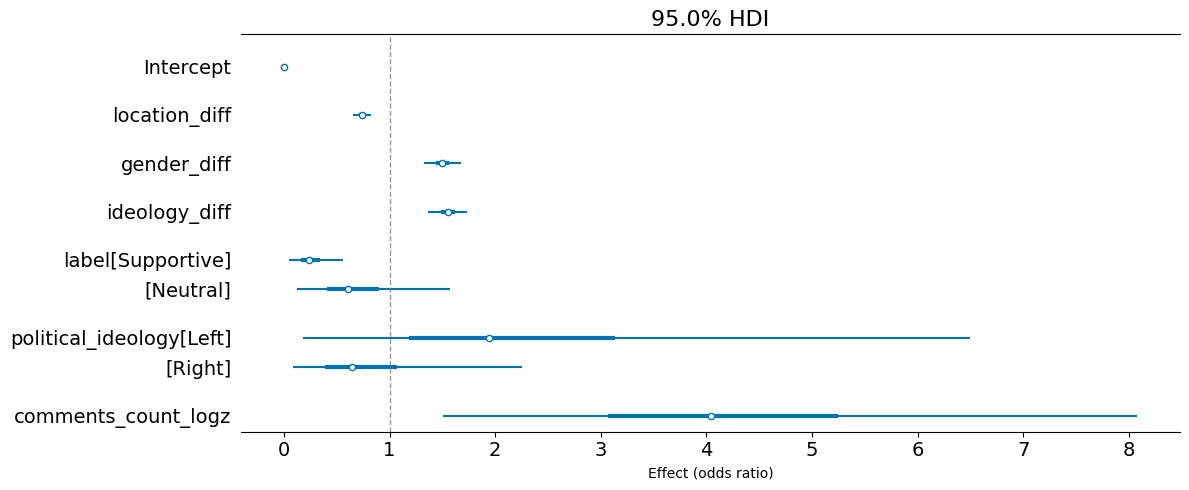

In [56]:
model = bmb.Model(
    "presence_no_rank ~ location_diff + gender_diff + ideology_diff + political_ideology + label + comments_count_logz + (1|urlid) + (1|comment)",
    data=reg_df,
    family="bernoulli",
    dropna=True,
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
    random_seed=42,
    weights = reg_df['weights']
)

var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'label', 'political_ideology',  'comments_count_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, location_diff, gender_diff, ideology_diff, political_ideology, label, comments_count_logz, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1102 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-5.875,0.734,-7.251,-4.492,0.010,0.008,5747.0,5612.0,1.0
location_diff[Yes],-0.306,0.059,-0.416,-0.194,0.000,0.001,17378.0,5786.0,1.0
gender_diff[Yes],0.406,0.060,0.289,0.514,0.000,0.001,19023.0,6253.0,1.0
ideology_diff[Yes],0.439,0.062,0.319,0.553,0.000,0.001,18257.0,5994.0,1.0
label[Supportive],-1.455,0.533,-2.472,-0.485,0.009,0.006,3840.0,4885.0,1.0
label[Neutral],-0.499,0.576,-1.595,0.580,0.009,0.006,3879.0,4913.0,1.0
political_ideology[Left],0.656,0.727,-0.724,2.043,0.008,0.008,9056.0,6434.0,1.0
political_ideology[Right],-0.440,0.751,-1.787,1.034,0.008,0.008,8121.0,5521.0,1.0
comments_count_logz,1.391,0.404,0.651,2.178,0.006,0.004,4999.0,5219.0,1.0


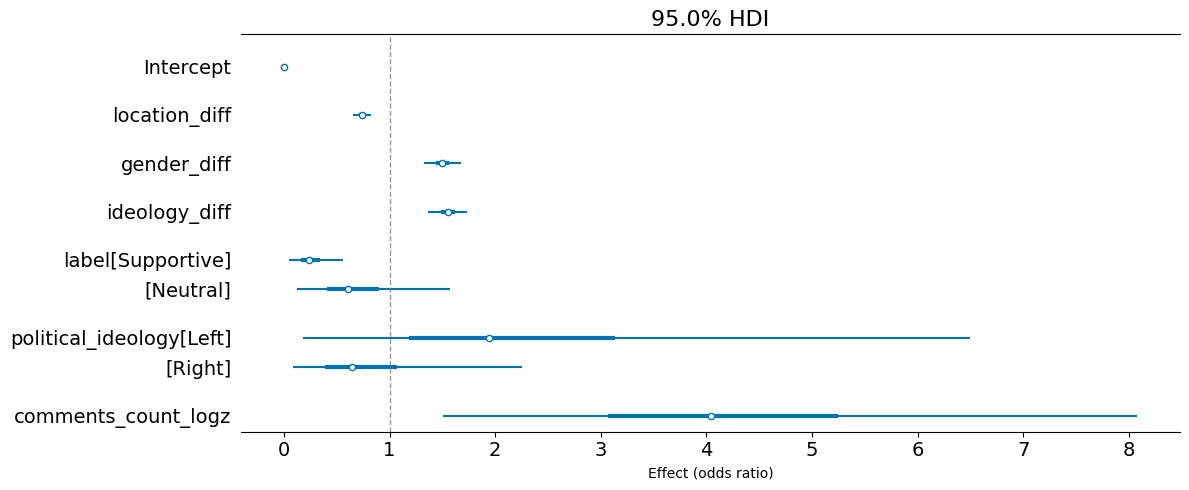

In [57]:
model = bmb.Model(
    "presence_no_rank ~ location_diff + gender_diff + ideology_diff + political_ideology + label + comments_count_logz + (1|urlid) + (1|comment)",
    data=reg_df,
    family="bernoulli",
    dropna=True,
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
    random_seed=42,
    # weights = reg_df['weights']
)

var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'label', 'political_ideology',  'comments_count_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()